# Pipeline Corregido — Arquitectura Híbrida + Validación Completa

## Correcciones respecto a la versión anterior

| Problema detectado | Solución aplicada |
|--------------------|-------------------|
| HRV plano (líneas constantes) | HRV se extrae **por ventana**, no como serie temporal |
| HRV repetido 600 veces en cada timestep | **Arquitectura híbrida**: rama temporal + rama HRV |
| No había validación de distribución por sujeto | Análisis completo antes de entrenar |

## Arquitectura del modelo (Fase B)
```
Entrada A: (600, 3)          Entrada B: (3,)
EDA, Temp, Resp              HR_mean, RMSSD, pNN50
     │                             │
  LSTM/GRU                      Dense(16)
     │                             │
     └──────── Concatenar ─────────┘
                    │
               Dense(32)
                    │
              Salida (1 neurona, sigmoid)
```

In [2]:

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, butter, filtfilt
from scipy import stats
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings('ignore')

# ─── RUTAS ────────────────────────────────────────────────────────────────────
WESAD_PATH = 'WESAD'
SUBJECTS   = ['S2','S3','S4','S5','S6','S7','S8','S9','S10','S11','S13','S14','S15','S16','S17']

# ─── PARÁMETROS ───────────────────────────────────────────────────────────────
FS          = 700
FS_10       = 10
DS_FACTOR   = FS // FS_10       # 70

WINDOW      = 600               # pasos a 10Hz = 60s
STRIDE      = 10                # 1s
HORIZON_A   = 200               # 20s para Fase A

# Zona precursora: experimentaremos con distintos valores
PRECURSOR_ZONES = [50, 100, 200, 300]  # 5s, 10s, 20s, 30s a 10Hz
PRECURSOR_ZONE  = 300                  # valor inicial: 30s

NEG_RATIO   = 3
STRESS      = 2
VALID_LBLS  = [1, 2, 3, 4]
LABEL_NAMES = {1:'Baseline', 2:'Stress', 3:'Amusement', 4:'Meditation'}
SIGNALS_TS  = ['EDA', 'Temp', 'Resp']     # serie temporal → rama LSTM
SIGNALS_HRV = ['HR_mean', 'RMSSD', 'pNN50']  # features agregadas → rama densa

SEED = 42
np.random.seed(SEED)
print('Configuración lista.')

Configuración lista.


## 1. Funciones de extracción de HRV

In [3]:
def bandpass_filter(signal, lowcut=0.5, highcut=40.0, fs=700, order=3):
    nyq = fs / 2
    b, a = butter(order, [lowcut/nyq, highcut/nyq], btype='band')
    return filtfilt(b, a, signal.flatten())


def extract_hrv(ecg_segment, fs=700):
    """
    Extrae HR_mean, RMSSD, pNN50 de un segmento de ECG.
    Esta función se llama UNA VEZ por ventana de entrenamiento,
    no por cada timestep.
    Retorna un vector de 3 features o [NaN, NaN, NaN] si falla.
    """
    try:
        ecg_f   = bandpass_filter(ecg_segment, fs=fs)
        min_d   = int(0.3 * fs)
        peaks,_ = find_peaks(ecg_f, distance=min_d, height=np.percentile(ecg_f, 75))
        if len(peaks) < 3:
            return np.array([np.nan, np.nan, np.nan])
        rr = np.diff(peaks) / fs * 1000
        rr = rr[(rr > 300) & (rr < 2000)]
        if len(rr) < 2:
            return np.array([np.nan, np.nan, np.nan])
        hr    = 60000 / np.mean(rr)
        rmssd = np.sqrt(np.mean(np.diff(rr)**2))
        pnn50 = np.mean(np.abs(np.diff(rr)) > 50) * 100
        return np.array([hr, rmssd, pnn50])
    except:
        return np.array([np.nan, np.nan, np.nan])

print('Función HRV lista (extracción por ventana, no por timestep).')

Función HRV lista (extracción por ventana, no por timestep).


## 2. Carga de señales por sujeto (sin HRV en la serie)

In [4]:
def load_subject(subject_id):
    """
    Carga señales del pecho a 10Hz.
    Retorna DataFrame con EDA, Temp, Resp (Z-score por sujeto),
    ECG_700 como array separado para extraer HRV por ventana después,
    y Label a 10Hz.
    """
    path = f'{WESAD_PATH}/{subject_id}/{subject_id}.pkl'
    with open(path, 'rb') as f:
        raw = pickle.load(f, encoding='latin1')

    chest    = raw['signal']['chest']
    lbl_700  = np.array(raw['label']).flatten()
    ecg_700  = np.array(chest['ECG']).flatten()
    eda_700  = np.array(chest['EDA']).flatten()
    temp_700 = np.array(chest['Temp']).flatten()
    resp_700 = np.array(chest['Resp']).flatten()

    T        = len(ecg_700)
    n10      = T // DS_FACTOR

    # Downsample continuas: media por bloque de 70
    eda_10  = eda_700[:n10*DS_FACTOR].reshape(n10, DS_FACTOR).mean(1)
    temp_10 = temp_700[:n10*DS_FACTOR].reshape(n10, DS_FACTOR).mean(1)
    resp_10 = resp_700[:n10*DS_FACTOR].reshape(n10, DS_FACTOR).mean(1)

    # Downsample etiquetas: moda
    lbl_10  = np.array([
        int(stats.mode(lbl_700[i*DS_FACTOR:(i+1)*DS_FACTOR], keepdims=True).mode[0])
        for i in range(n10)
    ])

    df = pd.DataFrame({'EDA': eda_10, 'Temp': temp_10, 'Resp': resp_10,
                       'Label': lbl_10, 'Subject_ID': subject_id})

    # Filtrar válidos y quitar primeros 300s
    df = df[df['Label'].isin(VALID_LBLS)].reset_index(drop=True)
    df = df.iloc[300*FS_10:].reset_index(drop=True)

    # Z-score por sujeto
    for col in SIGNALS_TS:
        m, s = df[col].mean(), df[col].std()
        df[col] = (df[col] - m) / (s + 1e-8)

    # ECG a 700Hz alineado con el DataFrame filtrado
    # Necesitamos el ECG correspondiente a cada fila del df
    # Las primeras 300s*10Hz = 3000 filas se eliminaron del df
    # pero el ECG está a 700Hz, así que el offset es 300*700 = 210000
    # Además, solo conservamos filas con label válida
    # Guardamos el índice original para mapear de vuelta al ECG_700
    df['orig_idx_10hz'] = df.index  # ya es el índice real tras filtrar

    return df, ecg_700, lbl_700


print('Función load_subject lista.')
print('ECG se guarda a 700Hz por separado para extracción de HRV por ventana.')

Función load_subject lista.
ECG se guarda a 700Hz por separado para extracción de HRV por ventana.


In [5]:
import os

PROCESSED_PATH = f'{WESAD_PATH}/wesad_10hz_sin_hrv.csv'

subject_data = {}  # {subj: (df_10hz, ecg_700, lbl_700)}

if os.path.exists(PROCESSED_PATH):
    print('Cargando señales procesadas...')
    df_all = pd.read_csv(PROCESSED_PATH)
    # ECG 700Hz se recarga del pkl cuando se necesita
    for subj in SUBJECTS:
        df_s = df_all[df_all['Subject_ID'] == subj].reset_index(drop=True)
        path = f'{WESAD_PATH}/{subj}/{subj}.pkl'
        with open(path, 'rb') as f:
            raw = pickle.load(f, encoding='latin1')
        ecg_700 = np.array(raw['signal']['chest']['ECG']).flatten()
        lbl_700 = np.array(raw['label']).flatten()
        subject_data[subj] = (df_s, ecg_700, lbl_700)
    print(f'Cargado: {df_all.shape}')
else:
    print('Procesando sujetos (2-3 minutos, sin HRV todavía)...')
    dfs = []
    for subj in SUBJECTS:
        print(f'  {subj}...', end=' ')
        df_s, ecg_700, lbl_700 = load_subject(subj)
        subject_data[subj] = (df_s, ecg_700, lbl_700)
        dfs.append(df_s)
        print(f'{len(df_s):,} filas')
    df_all = pd.concat(dfs, ignore_index=True)
    df_all.to_csv(PROCESSED_PATH, index=False)
    print(f'Guardado: {PROCESSED_PATH}')

Cargando señales procesadas...
Cargado: (404580, 6)


## 3. Construcción de ventanas con HRV extraído por ventana

### Cambio arquitectural clave
Cada muestra de entrenamiento ahora tiene DOS componentes:
- `X_ts`: tensor `(600, 3)` — serie temporal de EDA, Temp, Resp
- `X_hrv`: vector `(3,)` — HR_mean, RMSSD, pNN50 calculados sobre los mismos 60s

El HRV refleja el estado cardíaco del **intervalo completo de la ventana**,
no un valor instantáneo. Esto es fisiológicamente correcto.

In [6]:
def extract_hrv_for_window(ecg_700, start_10hz, window_10hz, ds_factor, fs):
    """
    Extrae HRV del segmento de ECG a 700Hz correspondiente a la ventana a 10Hz.
    
    start_10hz : índice de inicio en el eje de 10Hz
    window_10hz: tamaño de ventana en pasos de 10Hz
    """
    start_700 = start_10hz * ds_factor
    end_700   = (start_10hz + window_10hz) * ds_factor
    
    if end_700 > len(ecg_700):
        return np.array([np.nan, np.nan, np.nan])
    
    return extract_hrv(ecg_700[start_700:end_700], fs=fs)


def build_windows_hybrid(df_s, ecg_700, signals_ts, window, stride,
                          horizon=None, precursor_zone=None,
                          mode='phase_a', neg_ratio=3, rng=None):
    """
    Construye ventanas con salida híbrida: (X_ts, X_hrv, y).
    
    mode='phase_a' : multiclase, target = estado en t+horizon
    mode='phase_b' : binario, target = 1 si precursor de stress
    """
    data      = df_s[signals_ts].values
    label_arr = df_s['Label'].values
    T         = len(data)

    X_ts_list, X_hrv_list, y_list = [], [], []

    if mode == 'phase_a':
        for start in range(0, T - window - horizon + 1, stride):
            end_in     = start + window
            target_idx = end_in + horizon - 1
            if len(set(label_arr[start:end_in])) > 1:
                continue
            hrv = extract_hrv_for_window(ecg_700, start, window, DS_FACTOR, FS)
            X_ts_list.append(data[start:end_in])
            X_hrv_list.append(hrv)
            y_list.append(label_arr[target_idx] - 1)

    elif mode == 'phase_b':
        # Encontrar onsets de stress
        onsets = [i for i in range(1, T)
                  if label_arr[i] == STRESS and label_arr[i-1] != STRESS]
        if not onsets:
            return None

        # ── Positivos: zona precursora ────────────────────────────────────────
        for onset in onsets:
            zone_end   = onset - 1
            zone_start = max(window, onset - precursor_zone)
            for end_in in range(zone_start, zone_end + 1, stride):
                start = end_in - window
                if start < 0: continue
                seg_labels = label_arr[start:end_in]
                if STRESS in seg_labels: continue
                if len(set(seg_labels)) > 1: continue
                hrv = extract_hrv_for_window(ecg_700, start, window, DS_FACTOR, FS)
                X_ts_list.append(data[start:end_in])
                X_hrv_list.append(hrv)
                y_list.append(1)

        n_pos = sum(y_list)
        if n_pos == 0:
            return None

        # ── Negativos: estados estables alejados ──────────────────────────────
        forbidden = np.zeros(T, dtype=bool)
        for onset in onsets:
            f_start = max(0, onset - precursor_zone)
            f_end   = onset
            while f_end < T and label_arr[f_end] == STRESS:
                f_end += 1
            forbidden[f_start:f_end] = True

        neg_cands = []
        for start in range(0, T - window + 1, stride * 5):
            end_in = start + window
            if forbidden[start:end_in].any(): continue
            seg = label_arr[start:end_in]
            if len(set(seg)) > 1: continue
            if seg[0] == STRESS: continue
            neg_cands.append(start)

        n_neg = min(n_pos * neg_ratio, len(neg_cands))
        if n_neg == 0:
            return None
        chosen = rng.choice(neg_cands, size=n_neg, replace=False)
        for start in chosen:
            hrv = extract_hrv_for_window(ecg_700, start, window, DS_FACTOR, FS)
            X_ts_list.append(data[start:start+window])
            X_hrv_list.append(hrv)
            y_list.append(0)

    X_ts  = np.array(X_ts_list,  dtype=np.float32)
    X_hrv = np.array(X_hrv_list, dtype=np.float32)
    y     = np.array(y_list,     dtype=np.int32)
    return X_ts, X_hrv, y

print('Función build_windows_hybrid lista.')

Función build_windows_hybrid lista.


## 4. Análisis de validación ANTES de entrenar
### 4a. Distribución de positivos por sujeto (Fase B)
Verificamos que no haya sujetos que aporten casi todos los positivos.

In [7]:
print('=== ANÁLISIS DE POSITIVOS POR SUJETO (Fase B) ===')
print(f'Zona precursora actual: {PRECURSOR_ZONE/FS_10:.0f}s ({PRECURSOR_ZONE} pasos)\n')
print(f'{"Sujeto":8} {"Onsets":>8} {"Positivos":>10} {"Negativos cand":>16} {"Estado previo":>15}')
print('-' * 65)

pos_por_sujeto = {}
for subj in SUBJECTS:
    df_s, _, _ = subject_data[subj]
    labels = df_s['Label'].values
    onsets = [i for i in range(1, len(labels))
              if labels[i] == STRESS and labels[i-1] != STRESS]

    n_pos = 0
    for onset in onsets:
        zone_end   = onset - 1
        zone_start = max(WINDOW, onset - PRECURSOR_ZONE)
        for end_in in range(zone_start, zone_end + 1, STRIDE):
            start = end_in - WINDOW
            if start < 0: continue
            seg = labels[start:end_in]
            if STRESS in seg: continue
            if len(set(seg)) > 1: continue
            n_pos += 1

    estado_prev = LABEL_NAMES.get(labels[onsets[0]-1], '?') if onsets else 'N/A'
    pos_por_sujeto[subj] = n_pos
    print(f'{subj:8} {len(onsets):>8} {n_pos:>10} {n_pos*NEG_RATIO:>16} {estado_prev:>15}')

total_pos = sum(pos_por_sujeto.values())
print('-' * 65)
print(f'{"TOTAL":8} {"":>8} {total_pos:>10}')

# Alerta si algún sujeto aporta >30% de los positivos
print()
for subj, n in pos_por_sujeto.items():
    pct = n / total_pos * 100
    if pct > 30:
        print(f'⚠ ALERTA: {subj} aporta {pct:.1f}% de los positivos — posible sesgo')

=== ANÁLISIS DE POSITIVOS POR SUJETO (Fase B) ===
Zona precursora actual: 30s (300 pasos)

Sujeto     Onsets  Positivos   Negativos cand   Estado previo
-----------------------------------------------------------------
S2              1         30               90        Baseline
S3              1         30               90        Baseline
S4              1         30               90      Meditation
S5              1         30               90      Meditation
S6              1         30               90        Baseline
S7              1         30               90      Meditation
S8              1         30               90      Meditation
S9              1         30               90        Baseline
S10             1         30               90      Meditation
S11             1         30               90        Baseline
S13             1         30               90      Meditation
S14             1         30               90        Baseline
S15             1         30         

### 4b. Experimento de zona precursora — ¿cuándo aparecen las señales?

In [8]:
print('=== POSITIVOS POR TAMAÑO DE ZONA PRECURSORA ===')
print(f'{"Zona (s)":>10} {"Total positivos":>18} {"Positivos/sujeto (media)":>26}')
print('-' * 58)

for zone in PRECURSOR_ZONES:
    total = 0
    por_sujeto = []
    for subj in SUBJECTS:
        df_s, _, _ = subject_data[subj]
        labels = df_s['Label'].values
        onsets = [i for i in range(1, len(labels))
                  if labels[i] == STRESS and labels[i-1] != STRESS]
        n = 0
        for onset in onsets:
            zone_end   = onset - 1
            zone_start = max(WINDOW, onset - zone)
            for end_in in range(zone_start, zone_end + 1, STRIDE):
                start = end_in - WINDOW
                if start < 0: continue
                seg = labels[start:end_in]
                if STRESS in seg or len(set(seg)) > 1: continue
                n += 1
        total += n
        por_sujeto.append(n)
    media = np.mean(por_sujeto)
    print(f'{zone/FS_10:>10.0f} {total:>18} {media:>26.1f}')

print()
print('Interpretación:')
print('  Zona pequeña (5s) = solo detectar stress ya iniciado fisiológicamente')
print('  Zona grande (30s) = detectar precursores tempranos (más difícil, más valioso)')
print('  Experimenta con el modelo en distintas zonas y compara AUC-ROC')

=== POSITIVOS POR TAMAÑO DE ZONA PRECURSORA ===
  Zona (s)    Total positivos   Positivos/sujeto (media)
----------------------------------------------------------
         5                 75                        5.0
        10                150                       10.0
        20                300                       20.0
        30                450                       30.0

Interpretación:
  Zona pequeña (5s) = solo detectar stress ya iniciado fisiológicamente
  Zona grande (30s) = detectar precursores tempranos (más difícil, más valioso)
  Experimenta con el modelo en distintas zonas y compara AUC-ROC


### 4c. Visualización de señales por distancia al onset

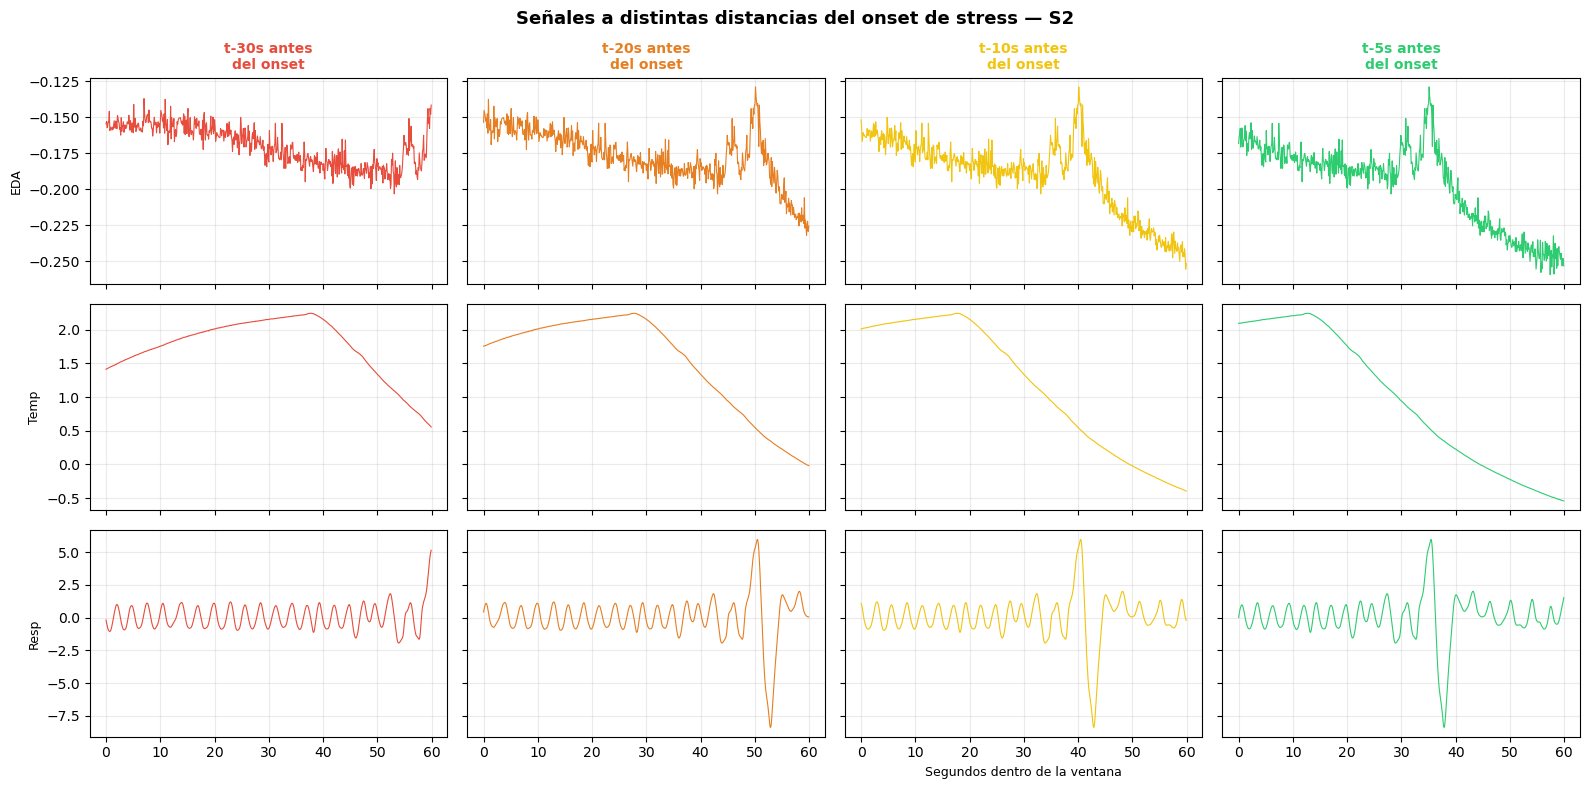

Observa si EDA muestra tendencia creciente más cerca del onset.
Si el patrón aparece solo en t-5s, la señal llega tarde.
Si aparece en t-30s, tienes forecasting preventivo real.


In [9]:
# Elegir un sujeto con transición y graficar EDA en distintos momentos
# antes del onset de stress
subj_demo = SUBJECTS[0]
df_s, _, _ = subject_data[subj_demo]
labels = df_s['Label'].values

onsets = [i for i in range(1, len(labels))
          if labels[i] == STRESS and labels[i-1] != STRESS]

if not onsets:
    print(f'{subj_demo} no tiene transiciones. Probando con siguiente sujeto...')
    for s in SUBJECTS[1:]:
        df_s, _, _ = subject_data[s]
        labels = df_s['Label'].values
        onsets = [i for i in range(1, len(labels))
                  if labels[i] == STRESS and labels[i-1] != STRESS]
        if onsets:
            subj_demo = s
            break

onset = onsets[0]
tiempo = np.arange(WINDOW) / FS_10
distancias = [300, 200, 100, 50]  # pasos antes del onset = 30s, 20s, 10s, 5s

fig, axes = plt.subplots(len(SIGNALS_TS), len(distancias),
                          figsize=(16, 8), sharex=True, sharey='row')
fig.suptitle(f'Señales a distintas distancias del onset de stress — {subj_demo}',
             fontsize=13, fontweight='bold')

colores = ['#E74C3C', '#E67E22', '#F1C40F', '#2ECC71']

for j, dist in enumerate(distancias):
    end_in = onset - dist
    start  = end_in - WINDOW
    if start < 0:
        continue
    axes[0, j].set_title(f't-{dist/FS_10:.0f}s antes\ndel onset', 
                          color=colores[j], fontsize=10, fontweight='bold')
    for i, sig in enumerate(SIGNALS_TS):
        axes[i, j].plot(tiempo, df_s[sig].values[start:end_in],
                        color=colores[j], linewidth=0.8)
        axes[i, j].grid(True, alpha=0.25)
        if j == 0:
            axes[i, j].set_ylabel(sig, fontsize=9)

axes[-1, len(distancias)//2].set_xlabel('Segundos dentro de la ventana', fontsize=9)
plt.tight_layout()
plt.show()
print('Observa si EDA muestra tendencia creciente más cerca del onset.')
print('Si el patrón aparece solo en t-5s, la señal llega tarde.')
print('Si aparece en t-30s, tienes forecasting preventivo real.')

## 5. Construir datasets finales (Fase A y B)

In [10]:
rng = np.random.default_rng(SEED)

# ─── Fase A ───────────────────────────────────────────────────────────────────
print('Construyendo Fase A (puede tardar ~10-15 min por extracción HRV)...')
windows_A, windows_B = {}, {}

for subj in SUBJECTS:
    df_s, ecg_700, _ = subject_data[subj]
    print(f'  {subj}...', end=' ')

    # Fase A
    result_a = build_windows_hybrid(
        df_s, ecg_700, SIGNALS_TS, WINDOW, STRIDE,
        horizon=HORIZON_A, mode='phase_a'
    )
    if result_a:
        windows_A[subj] = result_a  # (X_ts, X_hrv, y)

    # Fase B
    result_b = build_windows_hybrid(
        df_s, ecg_700, SIGNALS_TS, WINDOW, STRIDE,
        precursor_zone=PRECURSOR_ZONE, mode='phase_b',
        neg_ratio=NEG_RATIO, rng=rng
    )
    if result_b:
        windows_B[subj] = result_b
        n_pos = (result_b[2] == 1).sum()
        n_neg = (result_b[2] == 0).sum()
        print(f'A:{len(result_a[2]):,} | B: {n_pos}pos/{n_neg}neg')
    else:
        print(f'A:{len(result_a[2]):,} | B: sin transiciones')

print(f'\nFase A: {len(windows_A)} sujetos')
print(f'Fase B: {len(windows_B)} sujetos con transiciones')

Construyendo Fase A (puede tardar ~10-15 min por extracción HRV)...
  S2... A:2,274 | B: 30pos/90neg
  S3... A:2,320 | B: 30pos/90neg
  S4... A:2,355 | B: 30pos/90neg
  S5... A:2,396 | B: 30pos/90neg
  S6... A:2,374 | B: 30pos/90neg
  S7... A:2,373 | B: 30pos/90neg
  S8... A:2,390 | B: 30pos/90neg
  S9... A:2,375 | B: 30pos/90neg
  S10... A:2,458 | B: 30pos/90neg
  S11... A:2,404 | B: 30pos/90neg
  S13... A:2,406 | B: 30pos/90neg
  S14... A:2,406 | B: 30pos/90neg
  S15... A:2,412 | B: 30pos/90neg
  S16... A:2,398 | B: 30pos/90neg
  S17... A:2,392 | B: 30pos/90neg

Fase A: 15 sujetos
Fase B: 15 sujetos con transiciones


## 6. LOSO completo y class weights
Generador para los 15 folds. Los class weights se calculan
**solo sobre el train de cada fold**.

In [11]:
def loso_splits(windows_dict):
    """
    Generador de los N folds LOSO (uno por sujeto disponible).
    Yield: X_ts_tr, X_hrv_tr, y_tr, X_ts_te, X_hrv_te, y_te, test_subj, cw
    """
    subjects = list(windows_dict.keys())
    for test_subj in subjects:
        train_subjs = [s for s in subjects if s != test_subj]

        X_ts_tr  = np.concatenate([windows_dict[s][0] for s in train_subjs])
        X_hrv_tr = np.concatenate([windows_dict[s][1] for s in train_subjs])
        y_tr     = np.concatenate([windows_dict[s][2] for s in train_subjs])

        X_ts_te, X_hrv_te, y_te = windows_dict[test_subj]

        classes = np.unique(y_tr)
        weights = compute_class_weight('balanced', classes=classes, y=y_tr)
        cw = dict(zip(classes, weights))

        # Normalizar HRV con stats del train (evitar leakage)
        hrv_mean = np.nanmean(X_hrv_tr, axis=0)
        hrv_std  = np.nanstd(X_hrv_tr, axis=0) + 1e-8
        X_hrv_tr = (X_hrv_tr - hrv_mean) / hrv_std
        X_hrv_te = (X_hrv_te - hrv_mean) / hrv_std

        # Reemplazar NaN de HRV por 0 (media normalizada)
        X_hrv_tr = np.nan_to_num(X_hrv_tr, nan=0.0)
        X_hrv_te = np.nan_to_num(X_hrv_te, nan=0.0)

        yield X_ts_tr, X_hrv_tr, y_tr, X_ts_te, X_hrv_te, y_te, test_subj, cw


# Verificación rápida
print('=== VERIFICACIÓN LOSO FASE B ===')
for Xts_tr, Xhr_tr, y_tr, Xts_te, Xhr_te, y_te, subj, cw in loso_splits(windows_B):
    n_pos_te = (y_te==1).sum()
    n_neg_te = (y_te==0).sum()
    print(f'  Test={subj}: train={len(y_tr)} | '
          f'test pos={n_pos_te} neg={n_neg_te} | '
          f'HRV shape tr={Xhr_tr.shape} | cw={cw}')

print()
print('HRV normalizado con stats del train en cada fold — sin leakage.')
print('NaN reemplazados por 0 (media de la distribución normalizada).')

=== VERIFICACIÓN LOSO FASE B ===
  Test=S2: train=1680 | test pos=30 neg=90 | HRV shape tr=(1680, 3) | cw={np.int32(0): np.float64(0.6666666666666666), np.int32(1): np.float64(2.0)}
  Test=S3: train=1680 | test pos=30 neg=90 | HRV shape tr=(1680, 3) | cw={np.int32(0): np.float64(0.6666666666666666), np.int32(1): np.float64(2.0)}
  Test=S4: train=1680 | test pos=30 neg=90 | HRV shape tr=(1680, 3) | cw={np.int32(0): np.float64(0.6666666666666666), np.int32(1): np.float64(2.0)}
  Test=S5: train=1680 | test pos=30 neg=90 | HRV shape tr=(1680, 3) | cw={np.int32(0): np.float64(0.6666666666666666), np.int32(1): np.float64(2.0)}
  Test=S6: train=1680 | test pos=30 neg=90 | HRV shape tr=(1680, 3) | cw={np.int32(0): np.float64(0.6666666666666666), np.int32(1): np.float64(2.0)}
  Test=S7: train=1680 | test pos=30 neg=90 | HRV shape tr=(1680, 3) | cw={np.int32(0): np.float64(0.6666666666666666), np.int32(1): np.float64(2.0)}
  Test=S8: train=1680 | test pos=30 neg=90 | HRV shape tr=(1680, 3) | cw=

## 7. Guardar datasets

In [12]:
import os
SAVE_DIR = f'{WESAD_PATH}'

for phase, windows in [('A', windows_A), ('B', windows_B)]:
    save_dict = {}
    for s, (Xts, Xhr, y) in windows.items():
        save_dict[f'{s}_Xts']  = Xts
        save_dict[f'{s}_Xhr']  = Xhr
        save_dict[f'{s}_y']    = y
    save_dict['subjects'] = np.array(list(windows.keys()))
    path = f'{SAVE_DIR}/fase_{phase}_hybrid.npz'
    np.savez_compressed(path, **save_dict)
    size = os.path.getsize(path) / 1e6
    print(f'Guardado fase_{phase}_hybrid.npz: {size:.1f} MB')

print()
print('Para cargar en notebook de modelos:')
print("  data = np.load('fase_B_hybrid.npz', allow_pickle=True)")
print("  X_ts_S2  = data['S2_Xts']   # shape (n, 600, 3)")
print("  X_hrv_S2 = data['S2_Xhr']   # shape (n, 3)")
print("  y_S2     = data['S2_y']")

Guardado fase_A_hybrid.npz: 6.6 MB
Guardado fase_B_hybrid.npz: 7.9 MB

Para cargar en notebook de modelos:
  data = np.load('fase_B_hybrid.npz', allow_pickle=True)
  X_ts_S2  = data['S2_Xts']   # shape (n, 600, 3)
  X_hrv_S2 = data['S2_Xhr']   # shape (n, 3)
  y_S2     = data['S2_y']


---
## Resumen de correcciones aplicadas

| Problema anterior | Solución actual |
|-------------------|-----------------|
| HRV repetido como serie (líneas planas) | HRV = vector `(3,)` por ventana, extraído del ECG a 700Hz de **esa misma ventana** |
| HRV mezclado con señales temporales | Arquitectura híbrida: rama LSTM para EDA/Temp/Resp + rama densa para HRV |
| Class weights calculados sobre todo el dataset | Class weights calculados **solo sobre train** de cada fold |
| HRV normalizado globalmente | HRV normalizado con **stats del train** de cada fold |
| NaN de HRV no manejados | NaN → 0 después de normalización (= valor medio del train) |

## Siguiente paso
Con los `.npz` generados, el notebook de modelos implementará:
1. **Modelo LSTM híbrido Fase A** (multiclase, baseline experimental)
2. **Modelo LSTM híbrido Fase B** (binario, contribución principal)
3. Comparación LOSO completa con media ± std
4. Análisis de errores por sujeto y por tipo de transición